# Variational Continual Learning Reimplementation Task

This notebook is built to be run in Google Colab and reimplements the Deep Discriminative Model seen in the paper "Variational Continual Learning".

This notebook does not run the SI benchmark using the implementation found in the Avalanche Python API (this is from an older test). More information on Avalanche can be found here: https://avalanche-api.continualai.org/en/v0.6.0/index.html. For the SI benchmark, a custom MLP has been implemented from scratch, but the SI strategy is not custom implemented.

# Import Dependencies

In [1]:
# #@title [RUN] Install the Avalanche API
# #@markdown Install the Avalanche API used for the Synaptic Intelligence API
# !pip install avalanche-lib


In [2]:
#@title [RUN] Import Remaining Depencies
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import numpy as np
from torch.optim import Adam, SGD
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms
from sklearn.metrics import pairwise_distances_argmin_min
from tqdm import tqdm
import matplotlib.pyplot as plt
# Synaptic Intelligence from Avalanche
# from avalanche.training import SynapticIntelligence
# from avalanche.benchmarks import nc_benchmark
# from avalanche.benchmarks.utils import AvalancheDataset
# from avalanche.logging import InteractiveLogger
# from avalanche.evaluation.metrics import accuracy_metrics
# from avalanche.training.plugins import EvaluationPlugin
# from avalanche.benchmarks.classic import PermutedMNIST

In [3]:
#@title [RUN] Set device global and number of tasks

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
n_tasks = 5 #@param {type:"integer"}


# Get Datasets and DataLoaders

In [4]:
#@title [RUN] Coreset generation
#@markdown Random coreset selection with removal from original dataset
def get_random_coreset_from_loader(loader, n):
    data = list(loader)
    inputs = torch.cat([x for x, _ in data])
    targets = torch.cat([y for _, y in data])
    indices = torch.randperm(len(inputs))
    selected = indices[:n]
    remaining = indices[n:]

    coreset = DataLoader(list(zip(inputs[selected], targets[selected])), batch_size=n, shuffle=True)
    reduced = list(zip(inputs[remaining], targets[remaining]))
    return coreset, reduced

# def get_kcenter_coreset_from_loader(loader, n):
#     data = list(loader)
#     inputs = torch.cat([x for x, _ in data])
#     targets = torch.cat([y for _, y in data])
#     inputs_np = inputs.cpu().numpy()

#     selected_indices = [np.random.choice(len(inputs_np))]
#     while len(selected_indices) < n:
#         selected_pts = inputs_np[selected_indices]
#         _, distances = pairwise_distances_argmin_min(inputs_np, selected_pts)
#         next_idx = np.argmax(distances)
#         selected_indices.append(next_idx)

#     selected_indices = torch.tensor(selected_indices)
#     all_indices = torch.arange(len(inputs))
#     remaining_indices = all_indices[~torch.isin(all_indices, selected_indices)]

#     coreset = DataLoader(list(zip(inputs[selected_indices], targets[selected_indices])), batch_size=n, shuffle=True)
#     reduced = list(zip(inputs[remaining_indices], targets[remaining_indices]))
#     return coreset, reduced

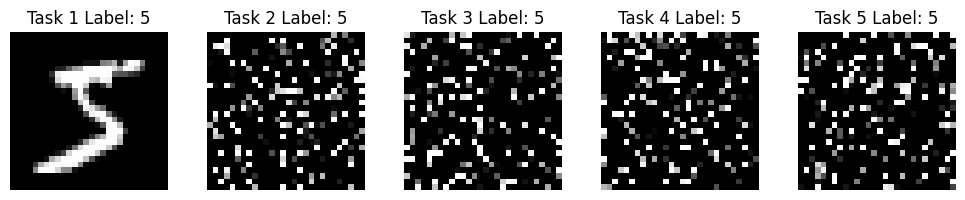

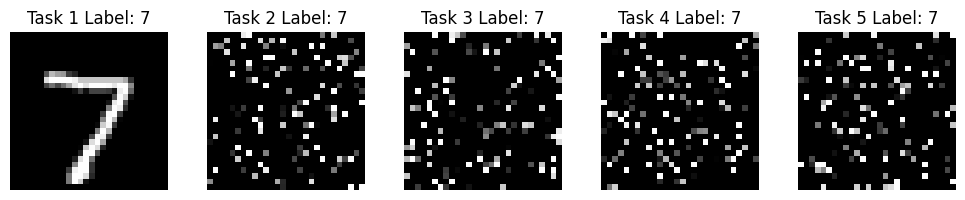

In [5]:
#@title Permuted MNIST
#@markdown Dataset generation for the Permuted MNIST benchmark.

#@markdown Code block also generates some example images from each task.


class PermutedMNISTDataset(Dataset):
    def __init__(self, base_dataset, permutation=None):
        self.base_dataset = base_dataset
        self.permutation = permutation

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        if self.permutation is not None:
          image, label = self.base_dataset[idx]
          image = image.view(-1)  # flatten to (784,)
          image = image[self.permutation]  # apply permutation
        else:
          image, label = self.base_dataset[idx]
          image = image.view(-1)
        return image, label

def get_permuted_mnist_tasks(n_tasks=10, seed=0):
    torch.manual_seed(seed)
    np.random.seed(seed)

    # Load raw MNIST
    mnist_train = datasets.MNIST(
        root='./data', train=True, download=True, transform=transforms.ToTensor()
    )
    mnist_test = datasets.MNIST(
        root='./data', train=False, download=True, transform=transforms.ToTensor()
    )

    input_size = 28 * 28
    permutations = [None]  # Identity for first task
    permutations += [np.random.permutation(input_size) for _ in range(n_tasks - 1)]

    train_datasets = []
    test_datasets = []

    for perm in permutations:
        train_datasets.append(PermutedMNISTDataset(mnist_train, perm))
        test_datasets.append(PermutedMNISTDataset(mnist_test, perm))

    return train_datasets, test_datasets

# Generate datasets based on the number of tasks defined earlier
pm_train, pm_test = get_permuted_mnist_tasks(n_tasks=n_tasks)

# Check Permutations
fig, axes = plt.subplots(1, n_tasks, figsize=(n_tasks*2, 2))
for i in range(n_tasks):
    img, label = pm_train[i][0]
    axes[i].imshow(img.view(28, 28), cmap='gray')
    axes[i].set_title(f"Task {i+1} Label: {label}")
    axes[i].axis('off')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, n_tasks, figsize=(n_tasks*2, 2))
for i in range(n_tasks):
    img, label = pm_test[i][0]
    axes[i].imshow(img.view(28, 28), cmap='gray')
    axes[i].set_title(f"Task {i+1} Label: {label}")
    axes[i].axis('off')
plt.tight_layout()
plt.show()

# Access using DataLoader(pm_train[i], batch=256, shuffle=True)

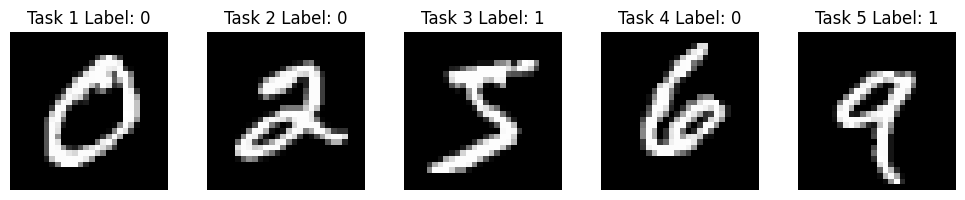

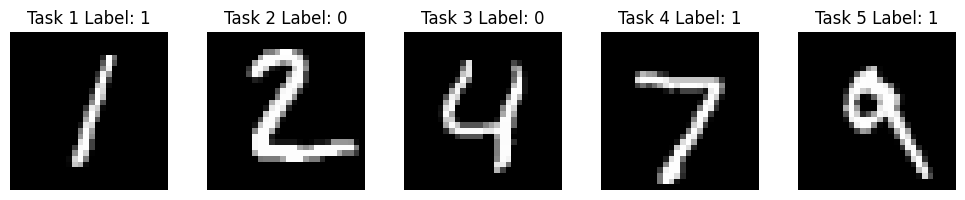

In [32]:
#@title Split MNIST
#@markdown Dataset generation for the Permuted MNIST benchmark.

#@markdown Code block also generates some example images from each task.


class SplitMNISTDataset(Dataset):
    def __init__(self, base_dataset, classes):
        self.base_dataset = base_dataset
        self.classes = classes
        self.indices = [i for i, (_, label) in enumerate(base_dataset) if label in classes]

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        actual_idx = self.indices[idx]
        image, label = self.base_dataset[actual_idx]
        # Remap labels to [0,1] for binary classification in each task
        label = self.classes.index(label)
        image = image.view(-1)  # Flatten to (784,)
        return image, label

def get_split_mnist_tasks(n_tasks=5):
    assert 10 % n_tasks == 0, "Number of tasks must evenly divide 10 classes"
    classes_per_task = 10 // n_tasks

    # Load raw MNIST
    mnist_train = datasets.MNIST(
        root='./data', train=True, download=True, transform=transforms.ToTensor()
    )
    mnist_test = datasets.MNIST(
        root='./data', train=False, download=True, transform=transforms.ToTensor()
    )

    train_datasets = []
    test_datasets = []

    for task_id in range(n_tasks):
        class_start = task_id * classes_per_task
        class_end = class_start + classes_per_task
        classes = list(range(class_start, class_end))

        train_datasets.append(SplitMNISTDataset(mnist_train, classes))
        test_datasets.append(SplitMNISTDataset(mnist_test, classes))

    return train_datasets, test_datasets

# Generate datasets
sm_train, sm_test = get_split_mnist_tasks(n_tasks=n_tasks)

# Check Permutations
fig, axes = plt.subplots(1, n_tasks, figsize=(n_tasks*2, 2))
for i in range(n_tasks):
    img, label = sm_train[i][0]
    axes[i].imshow(img.view(28, 28), cmap='gray')
    axes[i].set_title(f"Task {i+1} Label: {label}")
    axes[i].axis('off')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, n_tasks, figsize=(n_tasks*2, 2))
for i in range(n_tasks):
    img, label = sm_test[i][0]
    axes[i].imshow(img.view(28, 28), cmap='gray')
    axes[i].set_title(f"Task {i+1} Label: {label}")
    axes[i].axis('off')
plt.tight_layout()
plt.show()

In [9]:
import os
import tarfile
from google.colab import files

def upload_and_extract_notmnist(upload_path='/content', extract_path='/content/data/notmnist'):
    # Check if already extracted
    if os.path.exists(os.path.join(extract_path, 'notMNIST_large')) or os.path.exists(os.path.join(extract_path, 'notMNIST_small')):
        print(f"Dataset already extracted at {extract_path}.")
        return

    # Upload tar.gz
    print("Upload your notMNIST .tar.gz file (small or large).")
    uploaded = files.upload()
    uploaded_filename = next(iter(uploaded))
    tar_path = os.path.join(upload_path, uploaded_filename)
    print(f"Uploaded file: {tar_path}")

    # Extract
    os.makedirs(extract_path, exist_ok=True)
    print("Extracting...")
    with tarfile.open(tar_path, 'r:gz') as tar:
        tar.extractall(path=extract_path)
    print("Extraction complete!")

    print("Contents:")
    print(os.listdir(extract_path))

# Call it
upload_and_extract_notmnist()


Upload your notMNIST .tar.gz file (small or large).


Saving notMNIST_small.tar.gz.zip to notMNIST_small.tar.gz.zip
Uploaded file: /content/notMNIST_small.tar.gz.zip
Extracting...


ReadError: not a gzip file

# VCL Components

In [17]:
#@title KL Divergence Calculation

def kl_divergence(sigma_q, mu_q, sigma_p, mu_p):
    sigma_q = torch.clamp(sigma_q, min=1e-8)
    sigma_p = torch.clamp(sigma_p, min=1e-8)
    # From practical 2
    return torch.log(sigma_p / sigma_q) + (sigma_q**2 + (mu_q - mu_p)**2) / (2 * sigma_p**2) - 0.5

In [18]:
#@title BayesianLayer class
#@markdown This code block defines the Bayesian Layers
#@markdown that will compose the VCL model.

EPSILON = 1e-8

class BayesianLayer(nn.Module):
    def __init__(self, in_features, out_features, priors=None):
        super(BayesianLayer, self).__init__()
        self.in_features = in_features
        self.out_features = out_features

        if priors is None:
            priors = {
                'prior_mu': 0,
                'prior_sigma': 1.0,
            }
        self.prior_mu = torch.tensor(priors['prior_mu'])
        self.prior_sigma = torch.tensor(priors['prior_sigma'])
        self.prior_bias_mu = torch.tensor(priors['prior_mu'])
        self.prior_bias_sigma = torch.tensor(priors['prior_sigma'])

        # Want to keep rho instead of sigma because this prevents sigma < 0
        self.post_mu = nn.Parameter(torch.Tensor(out_features, in_features))
        self.post_rho = nn.Parameter(torch.Tensor(out_features, in_features))
        self.bias_mu = nn.Parameter(torch.Tensor(out_features))
        self.bias_rho = nn.Parameter(torch.Tensor(out_features))

        self.reset_parameters()

    def forward(self, input):   # S: Stochastic; or D: Deterministic
        # Retrieve standard deviations
        self.post_sigma = torch.log1p(torch.exp(self.post_rho))
        self.bias_sigma = torch.log1p(torch.exp(self.bias_rho))

        mu = F.linear(input, self.post_mu, self.bias_mu)
        var = EPSILON + F.linear(input ** 2, self.post_sigma ** 2, self.bias_sigma ** 2)
        sig = torch.sqrt(torch.clamp(var, min=EPSILON))

        if self.training:
            eps = torch.randn_like(sig)
            out = mu + sig * eps
        else:
            out = mu
        return out

    def reset_parameters(self):
        self.post_mu.data.normal_(0, 0.1)
        self.post_rho.data.fill_(-3)
        self.bias_mu.data.normal_(0, 0.1)
        self.bias_rho.data.fill_(-3)

    def get_kl_loss(self):
        kl_loss = kl_divergence(self.post_sigma, self.post_mu, self.prior_sigma, self.prior_mu).sum()
        kl_loss += kl_divergence(self.bias_sigma, self.bias_mu, self.prior_bias_sigma, self.prior_bias_mu).sum()
        return kl_loss

In [19]:
#@title VCLModel class
#@markdown Model that uses the Bayesian Layers.

#@markdown Hidden Layer widths are given as an array of
#@markdown widths. Supports multi/single head modes.

class VCLModel(nn.Module):
    def __init__(self, input_size, hidden_sizes, output_dim, n_tasks, multihead=False):
        super(VCLModel, self).__init__()
        self.input_size = input_size
        self.n_tasks = n_tasks
        self.multihead = multihead

        # Feature extractor (shared)
        self.layers = nn.ModuleList()
        self.layers.append(BayesianLayer(input_size, hidden_sizes[0]))
        for i in range(len(hidden_sizes) - 1):
            self.layers.append(BayesianLayer(hidden_sizes[i], hidden_sizes[i+1]))

        # Heads
        self.output_dim = output_dim
        if multihead:
            self.heads = nn.ModuleList([
                BayesianLayer(hidden_sizes[-1], output_dim) for _ in range(n_tasks)
            ])
        else:
            self.classifier = BayesianLayer(hidden_sizes[-1], output_dim)

    def forward(self, x, task_n=None):
        out = x.view(-1, self.input_size)
        for layer in self.layers:
            out = F.relu(layer(out))

        if self.multihead:
            return self.heads[task_n](out)
        else:
            return self.classifier(out)

    def get_kl(self, task_n=None):
        kl = 0.0
        for layer in self.layers:
            kl += layer.get_kl_loss()
        if self.multihead:
            kl += self.heads[task_n].get_kl_loss()
        else:
            kl += self.classifier.get_kl_loss()
        return kl

    def update_priors(self, task_n=None):
        for layer in self.layers:
            layer.prior_mu = layer.post_mu.data
            layer.prior_sigma = layer.post_sigma.data
            layer.prior_bias_mu = layer.bias_mu.data
            layer.prior_bias_sigma = layer.bias_sigma.data

        if self.multihead:
            head = self.heads[task_n]
            head.prior_mu = head.post_mu.data
            head.prior_sigma = head.post_sigma.data
            head.prior_bias_mu = head.bias_mu.data
            head.prior_bias_sigma = head.bias_sigma.data
        else:
            self.classifier.prior_mu = self.classifier.post_mu.data
            self.classifier.prior_sigma = self.classifier.post_sigma.data
            self.classifier.prior_bias_mu = self.classifier.bias_mu.data
            self.classifier.prior_bias_sigma = self.classifier.bias_sigma.data


In [20]:
#@title MLP

#@markdown Used for weight initialisation of Bayesian
#@markdown model. Trained on Task 1.


class MLP(nn.Module):
    def __init__(self, input_size, hidden_sizes, output_dim, n_tasks, multihead=False):
        super().__init__()
        self.multihead = multihead
        self.n_tasks = n_tasks

        layers = []
        prev_size = input_size
        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(prev_size, hidden_size))
            layers.append(nn.ReLU())
            prev_size = hidden_size

        self.feature_extractor = nn.Sequential(*layers)

        if multihead:
            self.heads = nn.ModuleList([
                nn.Linear(hidden_sizes[-1], output_dim) for _ in range(n_tasks)
            ])
        else:
            self.classifier = nn.Linear(hidden_sizes[-1], output_dim)

    def forward(self, x, task_id=0):
        x = x.view(x.size(0), -1)
        x = self.feature_extractor(x)
        if self.multihead:
            return self.heads[task_id](x)
        else:
            return self.classifier(x)


In [21]:
#@title Weight transfer function
#@markdown Function to transfer from MLP to VCL

def initialize_vcl_from_mlp(vcl_model, mlp_model, init_std=1e-3):
    vcl_layers = [l for l in vcl_model.layers if isinstance(l, BayesianLayer)]
    mlp_layers = [m for m in mlp_model.feature_extractor if isinstance(m, nn.Linear)]

    target_rho = torch.log(torch.exp(torch.tensor(init_std)) -1)
    for bl, ml in zip(vcl_layers, mlp_layers):
        bl.post_mu.data = ml.weight.data.clone()
        bl.bias_mu.data = ml.bias.data.clone()
        bl.post_rho.data.fill_(target_rho)
        bl.bias_rho.data.fill_(target_rho)

In [22]:
#@title ELBO Loss Calculation
#@markdown $\mathcal L = \text{CE} + \beta \text{KL}$

class ELBO_Loss(nn.Module):
    def __init__(self, beta):
        super(ELBO_Loss, self).__init__()
        self.beta = beta

    def forward(self, model, logits, y, task_n=None):
        assert not y.requires_grad
        ce = F.cross_entropy(logits, y, reduction='mean')
        kl_divergence = model.get_kl(task_n)
        elbo = ce + self.beta * kl_divergence
        return elbo

# EWC

In [53]:
#@title EWC Class
from collections import defaultdict
from torch.utils.data import Subset

class EWC():
    def __init__(self, model, dataloader, task_id, n_samples):
        self.model = model
        self.device = device
        self.dataloader = dataloader
        self.params = {n: p.clone().detach() for n, p in model.named_parameters() if p.requires_grad}
        self.n_samples = n_samples
        self.task_id = task_id
        self.fisher = self._compute_fisher()

    # def _compute_fisher(self):
    #     fisher = defaultdict(float)
    #     self.model.eval()

    #     for x, y in self.dataloader:
    #         x, y = x.to(self.device), y.to(self.device)
    #         self.model.zero_grad()
    #         output = self.model(x)
    #         loss = F.cross_entropy(output, y)
    #         loss.backward()

    #         for n, p in self.model.named_parameters():
    #             if p.grad is not None:
    #                 fisher[n] += p.grad.detach() ** 2

    #     for n in fisher:
    #         fisher[n] /= len(self.dataloader)

    #     return fisher

    def _compute_fisher(self):
        fisher = defaultdict(float)
        self.model.eval()

        # Sample n_samples random indices from the dataset
        dataset = self.dataloader.dataset  # assume DataLoader wraps a Dataset
        indices = np.random.choice(len(dataset), size=min(self.n_samples, len(dataset)), replace=False)
        subset = Subset(dataset, indices)
        loader = DataLoader(subset, batch_size=self.n_samples, shuffle=False)

        for x, y in loader:
            x, y = x.to(self.device), y.to(self.device)
            self.model.zero_grad()
            output = self.model(x, self.task_id)
            loss = F.cross_entropy(output, y)
            loss.backward()

            for n, p in self.model.named_parameters():
                if p.grad is not None:
                    fisher[n] += p.grad.detach() ** 2

        for n in fisher:
            fisher[n] /= self.n_samples

        return fisher

    def penalty(self, model):
        loss = 0.0
        for n, p in model.named_parameters():
            if p.requires_grad:
                loss += (self.fisher[n] * (p - self.params[n]) ** 2).sum()
        return loss

# SI Components

In [6]:
#@title MLP for SI Strategy

class SI_MLP(nn.Module):
    def __init__(self, input_size, hidden_sizes, output_dim, n_tasks, multihead=False):
        super().__init__()
        self.multihead = multihead
        if self.multihead:
            self.current_task_id = None
        self.n_tasks = n_tasks

        layers = []
        prev_size = input_size
        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(prev_size, hidden_size))
            layers.append(nn.ReLU())
            prev_size = hidden_size

        self.feature_extractor = nn.Sequential(*layers)

        if multihead:
            self.heads = nn.ModuleList([
                nn.Linear(hidden_sizes[-1], output_dim) for _ in range(n_tasks)
            ])
        else:
            self.classifier = nn.Linear(hidden_sizes[-1], output_dim)

    def forward(self, x, task_id=None):
        x = x.view(x.size(0), -1)
        features = self.feature_extractor(x)

        if self.multihead:
            task_id = self.current_task_id if task_id is None else task_id
            return self.heads[task_id](features)
        else:
            return self.classifier(features)

    def set_task_id(self, task_id):
        self.current_task_id = task_id

In [17]:
#@title Initialise SI buffers

def init_si(model):
    for name, param in model.named_parameters():
        if param.requires_grad:
            param.si_W = torch.zeros_like(param.data)
            param.si_total_delta = torch.zeros_like(param.data)
            param.si_omega = torch.zeros_like(param.data)
            param.si_prev = param.data.clone().detach()  # for tracking total movement
            param.si_task_final = param.data.clone().detach()  # for SI penalty reference

In [18]:
#@title Accumulate SI contributions

def accumulate_contributions(model):
    for name, param in model.named_parameters():
        if param.requires_grad and param.grad is not None:
            delta = param.data - param.si_prev
            param.si_W += -param.grad * delta  # accumulate contribution
            param.si_total_delta += delta      # accumulate total movement
            # param.si_prev = param.data.clone() # update prev for next step

    # print(param.si_W.max())
    # print(param.si_W.min())


def accumulate_contributions_whole_task(model):
    for name, param in model.named_parameters():
        if param.requires_grad:
            delta = param.data - param.si_prev  # total parameter movement over task
            param.si_W += -param.si_prev_grad * delta  # contribution: starting grad × delta
            param.si_total_delta += delta  # accumulate total movement

In [25]:
#@title Update Omega after each task

def update_omega(model, epsilon=1e-3):
    for name, param in model.named_parameters():
        if param.requires_grad:
            delta = param.si_total_delta

            model_param_omega = param.si_W / (delta.pow(2) + epsilon)

            # Update running omega
            param.si_omega += model_param_omega

            # Save final trained parameters for SI regularization
            param.si_task_final = param.data.clone().detach()

            # Reset buffers for next task
            param.si_W.zero_()
            param.si_total_delta.zero_()
            param.si_prev = param.data.clone().detach()

In [21]:
#@title Regularisation Loss

def compute_si_reg_loss(model, c):
    reg_loss = 0.0
    for name, param in model.named_parameters():
        if param.requires_grad:
            # Penalize distance from the last task's final parameters
            reg_loss += torch.sum(param.si_omega * (param.data - param.si_task_final).pow(2))
    return c * reg_loss

# Training and Evaluation Loops

## Permuted MNIST VCL

In [33]:
#@title Training Loop

def vcl_train(model, train_loader, optim, crit, n_epochs, task_n, MCs, out_dim=10, desc=''):
    # Set the model to train mode
    model.train()

    # Begin training loop
    for epoch in tqdm(range(n_epochs), desc=desc):

        # Per batch
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optim.zero_grad()

            # Make a matrix of T sample answers to perform Monte Carlo approximation
            outputs = torch.zeros(x.size(0), out_dim, MCs, device=device)
            for s in range(MCs):
                outputs[:, :, s] = model(x, task_n)
            logits = outputs.mean(dim=-1)

            # Loss and backward pass
            loss = crit(model, logits, y, task_n=task_n)
            loss.backward()
            optim.step()

In [34]:
#@title Evaluation Loop

def vcl_eval(model, dataloader, out_dim, task_id, MCs=10):
    # Set the model into evaluation mode
    model.eval()

    # List of accuracy values
    accs = []
    for inputs, targets in dataloader:
        inputs, targets = inputs.to(device), targets.to(device)

        # Make a matrix of MCs sample answers to perform Monte Carlo approximation
        outputs = torch.zeros(inputs.shape[0], out_dim, MCs, device=device)
        for s in range(MCs):
            with torch.no_grad():
                net_out = model(inputs, task_id)
            outputs[:, :, s] = F.log_softmax(net_out, dim=-1)

        # Average outputs to find answer
        log_output = torch.logsumexp(outputs, dim=-1) - np.log(MCs)
        accs.append(np.mean(log_output.argmax(dim=-1).cpu().numpy() == targets.cpu().numpy()))

    return np.mean(accs)

In [35]:
#@title Combined Training and Evaluation Loops
#@markdown These are the functions that should be run by the user:
#@markdown - `vcl_train_and_evaluate` (Train on all tasks' full datasets)
#@markdown - `coreset_only` (Train only on coresets)


# Train on all + Coreset (if applicable)
def vcl_train_and_evaluate(model, train_datasets, test_datasets, n_epochs=10, batch_size=256,
                          lr=1e-3, c_size=0, MCs=10, n_outs=10, multihead=False):
    # Put the model on the GPU
    model.to(device)
    optimizer = Adam(model.parameters(), lr=lr)
    optim = Adam(model.parameters(), lr=lr)
    crit = ELBO_Loss(1/len(train_datasets[0]))

    # Initialise test loaders (these will be referenced multiple times in training)
    all_test_loaders = [DataLoader(ds, batch_size=batch_size, shuffle=False) for ds in test_datasets]
    coresets = []

    mlp = MLP(input_size=28*28, hidden_sizes=mlp_hiddens, output_dim=n_outs, n_tasks=n_tasks, multihead=multihead).to(device)
    loader = DataLoader(train_datasets[0], batch_size=batch_size, shuffle=True)
    for epoch in tqdm(range(n_epochs), desc='Training MLP'):
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            logits = mlp(x, 0)
            loss = F.cross_entropy(logits, y)
            loss.backward()
            optimizer.step()
    initialize_vcl_from_mlp(model, mlp)

    # Accuracy scores matrix
    accuracy_scores = np.empty(shape=(n_tasks, n_tasks))
    accuracy_scores.fill(np.nan)


    for task in range(n_tasks):
        # Training dataloader
        train_loader = DataLoader(train_datasets[task], batch_size=batch_size, shuffle=True)

        # Update coreset and training dataloader
        print(f'Updating coreset for task {task+1}')
        if c_size > 0:
            new_c, train_data = get_random_coreset_from_loader(train_loader, c_size)
            train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
            coresets.append(new_c)

        # Train on current task
        vcl_train(model, train_loader=train_loader, optim=optim, crit=crit,
                  n_epochs=n_epochs, task_n=task, MCs=MCs, out_dim=n_outs,
                  desc=f'Training Task {task+1}')

        # Retrain on coresets
        if c_size > 0:
            for i, coreset in enumerate(coresets):
                vcl_train(model, train_loader=coreset, optim=optim, crit=crit,
                          n_epochs=n_epochs, task_n=i, MCs=MCs, out_dim=n_outs,
                          desc=f'Retraining model for Coreset Task {i+1}')

        # Evaluate on all tasks up to current
        for i in range(0, task+1):
            # Open up the i-th test loader
            test_loader = all_test_loaders[i]
            acc_i = vcl_eval(model=model, dataloader=test_loader, out_dim=n_outs, task_id=i, MCs=MCs)
            print("Task {} Accuracy: {}".format(i + 1, acc_i))
            accuracy_scores[task, i] = acc_i

        model.update_priors(task_n=task)
    print(accuracy_scores)
    return accuracy_scores

# Coreset Only
def coreset_only(model, train_datasets, test_datasets, n_epochs=10, lr=1e-3,
                 c_size=200, MCs=10, out_dim=10, batch_size=None, multihead=False):
    if batch_size is None:
        batch_size=c_size
    model.to(device)
    optimizer = Adam(model.parameters(), lr=lr)
    crit = ELBO_Loss(1/c_size)

    # Initialise test loaders (these will be referenced multiple times in training)
    all_test_loaders = [DataLoader(ds, batch_size=batch_size, shuffle=False) for ds in test_datasets]
    coresets = []

    mlp = MLP(input_size=28*28, hidden_sizes=[100,100], output_dim=10, n_tasks=n_tasks, multihead=multihead).to(device)

    # Set up the first task coreset
    train_loader = DataLoader(train_datasets[0], batch_size=batch_size, shuffle=True)

    new_c, train_data = get_random_coreset_from_loader(train_loader, c_size)
    train_loader = new_c
    # coresets.append(new_c)

    # Train an MLP for the first task
    for epoch in tqdm(range(n_epochs), desc='Training MLP'):
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            logits = mlp(x, 0)
            loss = F.cross_entropy(logits, y)
            loss.backward()
            optimizer.step()
    initialize_vcl_from_mlp(model, mlp)

    optimizer = Adam(model.parameters(), lr=lr)

    accuracy_scores = np.empty(shape=(n_tasks, n_tasks))
    accuracy_scores.fill(np.nan)

    # Train for all tasks on the VCL model
    for task in range(n_tasks):

        print(f'Updating coreset for task {task+1}')
        train_loader = DataLoader(train_datasets[task], batch_size=batch_size, shuffle=True)
        new_c, _ = get_random_coreset_from_loader(train_loader, c_size)
        train_loader = new_c
        coresets.append(new_c)

        # Train on current task
        vcl_train(model, train_loader, optimizer, crit, n_epochs, task, MCs,
                  out_dim, desc=f'Training Task {task+1}')

        if c_size > 0:
            for i, coreset in enumerate(coresets):
                vcl_train(model, coreset, optimizer, crit, n_epochs, task, MCs,
                  out_dim, desc=f'Retraining model for Coreset Task {i+1}')

        # Evaluate on all tasks up to current
        for i in range(0, task+1):
            acc_i = vcl_eval(model, all_test_loaders[i], out_dim, i, MCs)
            print("Task {} Accuracy: {}".format(i + 1, acc_i))
            accuracy_scores[task, i] = acc_i

        model.update_priors(task_n=task)
    print(accuracy_scores)
    return accuracy_scores

## Permuted MNIST EWC

In [36]:
#@title Train

def train_ewc(model, optimizer, train_loader, ewc_list=None, lambda_ewc=1000.0, num_epochs=20, task_id=None):
    model.train()
    for epoch in tqdm(range(num_epochs)):
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()

            logits = model(x, task_id)
            loss = F.cross_entropy(logits, y)

            if ewc_list:
                for ewc in ewc_list:
                    loss += lambda_ewc * ewc.penalty(model)

            loss.backward()
            optimizer.step()

In [37]:
#@title Evaluate

def evaluate_ewc(model, data_loader, task_id=None):
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for x, y in data_loader:
            x, y = x.to(device), y.to(device)
            logits = model(x, task_id)
            preds = torch.argmax(logits, dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)
    return correct / total

In [38]:
#@title Combined

def train_and_evaluate_ewc(model, train_sets, test_sets, num_epochs=20, batch_size=256, lr=1e-3, lambda_ewc=1000.0, n_samples=600):

    # Move model to the GPU
    model.to(device)
    optimizer = Adam(model.parameters(), lr=lr)

    # Store EWC values
    ewc_list = []

    # Initialise accuracies
    accuracy_scores = np.empty(shape=(n_tasks, n_tasks))
    accuracy_scores.fill(np.nan)

    for task_id, train_set in enumerate(train_sets):
        print(f"\n--- Task {task_id} ---")

        train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
        # Train with EWC penalty from all previous tasks
        train_ewc(model, optimizer, train_loader, ewc_list, lambda_ewc, num_epochs, task_id)

        # Store EWC info for this task
        ewc = EWC(model, train_loader, task_id, n_samples)
        ewc_list.append(ewc)

        # Evaluate on all tasks seen so far
        for test_id in range(task_id + 1):
            test_loader = DataLoader(test_sets[test_id], batch_size=batch_size, shuffle=False)
            acc = evaluate_ewc(model, test_loader, test_id)
            accuracy_scores[task_id, test_id] = acc
            print(f"Accuracy on Task {test_id}: {acc:.4f}")

        print(f"Accuracy Matrix:\n{np.array(accuracy_scores)}")
    return accuracy_scores


## Permuted MNIST DLP

In [52]:
#@title Train

def train_diagonal_lp(model, train_dataset, task_id, previous_means=None, previous_vars=None,
                      lambda_=1.0, epochs=20, lr=0.001, batch_size=128, n_samples=1024):
    model.train()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    param_names = [n for n, p in model.named_parameters() if p.requires_grad]
    params = {n: p for n, p in model.named_parameters() if p.requires_grad}

    for epoch in tqdm(range(epochs)):
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            outputs = model(x, task_id)
            loss = F.nll_loss(F.log_softmax(outputs, dim=1), y)

            if previous_means is not None:
                kl = 0.0
                for name in param_names:
                    mu_prev = previous_means[name]
                    var_prev = previous_vars[name]
                    mu = params[name]
                    kl += (1 / var_prev * (mu - mu_prev) ** 2).sum()
                loss += 0.5 * lambda_ * kl

            loss.backward()
            optimizer.step()

    # === Fisher Information Estimation ===
    model.eval()
    total_samples = len(train_dataset)
    selected_indices = np.random.choice(total_samples, size=min(n_samples, total_samples), replace=False)
    fisher_subset = Subset(train_dataset, selected_indices)
    fisher_loader = DataLoader(fisher_subset, batch_size=n_samples, shuffle=False)

    fisher_diag = defaultdict(lambda: 0)
    for x, y in fisher_loader:
        x, y = x.to(device), y.to(device)
        model.zero_grad()
        outputs = model(x, task_id)
        loss = F.nll_loss(F.log_softmax(outputs, dim=1), y)
        loss.backward()

        for name in param_names:
            if params[name].grad is not None:
                fisher_diag[name] += (params[name].grad.detach() ** 2)

    new_means = {name: params[name].detach().clone() for name in param_names}
    new_vars = {name: 1.0 / (lambda_ + fisher_diag[name]) for name in param_names}

    return new_means, new_vars


In [40]:
#@title Evaluate

def evaluate_diagonal_lp(model, dataset, task_id, batch_size=128):
    model.eval()
    loader = DataLoader(dataset, batch_size=batch_size)
    correct = total = 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            outputs = model(x, task_id)
            preds = outputs.argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)

    return correct / total

In [41]:
#@title Combined

def train_and_evaluate_diagonal_lp(model, train_datasets, test_datasets, epochs, lr, lambda_si, n_tasks,
                                   batch_size=128, multihead=False, n_samples=1024):
    model = model.to(device)

    acc_matrix = np.full((n_tasks, n_tasks), np.nan)
    previous_means = None
    previous_vars = None

    for task_id in range(n_tasks):
        print(f"\nTraining on task {task_id}")
        previous_means, previous_vars = train_diagonal_lp(
            model=model,
            train_dataset=train_datasets[task_id],
            task_id=task_id,
            previous_means=previous_means,
            previous_vars=previous_vars,
            lambda_=lambda_si,
            epochs=epochs,
            lr=lr,
            batch_size=batch_size,
            n_samples=n_samples
        )

        for eval_id in range(task_id + 1):
            acc = evaluate_diagonal_lp(model, test_datasets[eval_id], task_id=eval_id, batch_size=batch_size)
            acc_matrix[task_id, eval_id] = acc
            print(f"Accuracy on task {eval_id}: {acc:.4f}")

    return acc_matrix


## Synaptic Intelligence

In [37]:
#@title Train SI

# def train_si(model, optimizer, train_loader, task_id, lambda_si=0.5, num_epochs=10):

#     model.train()
#     for epoch in range(num_epochs):
#         total_loss = 0.0
#         for x, y in train_loader:
#             x, y = x.to(device), y.to(device)

#             optimizer.zero_grad()
#             output = model(x, task_id)

#             ce_loss = F.cross_entropy(output, y)
#             if task_id > 0:
#                 si_reg = compute_si_reg_loss(model, lambda_si)
#                 loss = ce_loss + si_reg
#             else:
#                 loss = ce_loss

#             loss.backward()
#             optimizer.step()
#             accumulate_contributions(model)

#             total_loss += loss.item()
#         print(f"[Task {task_id+1}] Epoch {epoch+1}/{num_epochs} - Loss: {total_loss:.4f}; SI Reg Loss: {si_reg.item():.4f}")

#     update_omega(model)

def train_si(model, optimizer, train_loader, task_id, lambda_si=5.0, num_epochs=10):
    model.train()

    # Step 1: Save initial gradients
    x, y = next(iter(train_loader))
    x, y = x.to(device), y.to(device)
    optimizer.zero_grad()
    output = model(x, task_id)
    ce_loss = F.cross_entropy(output, y)
    ce_loss.backward()
    for name, param in model.named_parameters():
        if param.requires_grad:
            # Check if param.grad is None before cloning
            if param.grad is not None:
                param.si_prev_grad = param.grad.clone().detach()
            else:
                # Handle the case where param.grad is None
                # For example, initialize it with zeros:
                param.si_prev_grad = torch.zeros_like(param.data)
                print(f"Warning: param.grad is None for parameter '{name}'. Initializing si_prev_grad with zeros.")

    # Step 2: Train normally
    for epoch in range(num_epochs):
        total_loss = 0.0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)

            # Save parameters before the optimizer step
            theta_old = {}
            for name, param in model.named_parameters():
                if param.requires_grad:
                    theta_old[name] = param.data.clone()

            # Forward pass
            optimizer.zero_grad()
            output = model(x, task_id)
            ce_loss = F.cross_entropy(output, y)
            if task_id > 0:
                si_reg = compute_si_reg_loss(model, lambda_si)
                loss = ce_loss + si_reg
            else:
                loss = ce_loss

            # Backward and optimizer step
            loss.backward()
            optimizer.step()

            # After stepping optimizer, accumulate SI contributions
            for name, param in model.named_parameters():
                if param.requires_grad and param.grad is not None:
                    delta = param.data - theta_old[name]
                    param.si_W += -param.grad.detach() * delta.detach()
                    param.si_total_delta += delta.detach()

            total_loss += loss.item()

        if task_id > 0:
            print(f"[Task {task_id+1}] Epoch {epoch+1}/{num_epochs} - Loss: {total_loss:.4f}; SI Reg Loss: {si_reg.item():.4f}")
        else:
            print(f"[Task {task_id+1}] Epoch {epoch+1}/{num_epochs} - Loss: {total_loss:.4f}")
    # Step 3: Accumulate contributions over the entire task
    accumulate_contributions_whole_task(model)

    # Step 4: Update omega
    update_omega(model)


In [12]:
#@title Evaluate SI

def evaluate_si(model, test_loader, task_id):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            output = model(x, task_id)
            pred = output.argmax(dim=1)
            correct += (pred == y).sum().item()
            total += y.size(0)
    accuracy = 100.0 * correct / total
    print(f"[Task {task_id}] Test Accuracy: {accuracy}%")
    return accuracy

In [13]:
#@title Combined SI Loop

def si_train_and_evaluate(model, train_datasets, test_datasets, n_epochs=10, batch_size=256,
                          lr=1e-3, lambda_si=0.5):

    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    all_test_loaders = [DataLoader(ds, batch_size=batch_size, shuffle=False) for ds in test_datasets]

    # Initialize SI-specific buffers
    init_si(model)

    n_tasks = len(train_datasets)
    accuracy_scores = np.full((n_tasks, n_tasks), np.nan)

    for task in range(n_tasks):
        print(f"\n🎯 Training on Task {task+1}")

        # Prepare training data
        train_loader = DataLoader(train_datasets[task], batch_size=batch_size, shuffle=True)

        # Train on current task with SI
        train_si(model, optimizer, train_loader, task_id=task,
                 lambda_si=lambda_si, num_epochs=n_epochs)

        # Evaluate on all tasks up to current
        for i in range(task + 1):
            acc_i = evaluate_si(model, all_test_loaders[i], i)
            print(f"✅ Task {i+1} Accuracy: {acc_i}%")
            accuracy_scores[task, i] = acc_i

        print(f"📌 Finished Task {task+1}")
        print(f"Current Accuracy Table (after Task {task+1}):\n{accuracy_scores[:task+1, :task+1]}")

    return accuracy_scores

# Run Experiments

## Permuted MNIST

In [15]:
#@title [RUN] Setting up parameters
input_size = 28 * 28 #@param

In [ ]:
#@title VCL
vcl_lr = 1e-3 #@param {type:"number"}
vcl_mcs = 10 #@param {type:"integer"}


for seed in range(5):
    torch.manual_seed(seed)
    np.random.seed(seed)

    # Split MNIST
    print('*****SplitMNIST*****')
    vcl_epochs=120
    vcl_beta = 1/len(sm_train[0])
    vcl_c_size = 40
    output_dim = 2
    hidden_sizes = [256, 256]

    # Run by training on only coreset
    model = VCLModel(input_size, hidden_sizes, output_dim, n_tasks, multihead=True)
    print(f'VCL with SplitMNIST, coreset only, run {seed+1}')
    sm_co_accuracy = coreset_only(model, sm_train, sm_test, vcl_epochs, vcl_lr, vcl_c_size,
                                  vcl_mcs, output_dim, multihead=True)
    sm_accs = np.nanmean(sm_co_accuracy, axis=1)
    print(f'Coreset Only Run {seed+1} Accuracy after each task: {sm_accs}')

    # Run with random coreset
    model = VCLModel(input_size, hidden_sizes, output_dim, n_tasks, multihead=True)
    print(f'VCL with SplitMNIST, random coreset, run {seed+1}')
    sm_rc_accuracy = vcl_train_and_evaluate(model, sm_train, sm_test, vcl_epochs,
                                            len(sm_train[0]), vcl_lr, vcl_c_size,
                                            vcl_mcs, n_outs=output_dim, multihead=True)
    sm_accs = np.nanmean(sm_rc_accuracy, axis=1)
    print(f'Random Coreset Run {seed+1} Accuracy after each task: {sm_accs}')


    # Permuted MNIST
    print('*****Permuted MNIST*****')
    vcl_epochs=100
    vcl_beta = 1/len(pm_train[0])
    vcl_c_size = 200
    output_dim = 10
    hidden_sizes = [100, 100]

    # Run with random coreset
    model = VCLModel(input_size, hidden_sizes, output_dim, n_tasks, multihead=False)
    print(f'VCL with Permuted MNIST, random coreset, run {seed+1}')
    pm_rc_accuracy = vcl_train_and_evaluate(model, pm_train, pm_test, vcl_epochs,
                                            256, vcl_lr, vcl_c_size,
                                            vcl_mcs, n_outs=output_dim)
    pm_accs = np.nanmean(pm_rc_accuracy, axis=1)
    print(f'Random Coreset Run {seed+1} Accuracy after each task: {pm_accs}')

    # Run by training on only coreset
    model = VCLModel(input_size, hidden_sizes, output_dim, n_tasks, multihead=False)
    print(f'VCL with Permuted MNIST, coreset only, run {seed+1}')
    pm_co_accuracy = coreset_only(model, pm_train, pm_test, vcl_epochs, vcl_lr, vcl_c_size,
                                  vcl_mcs, output_dim)
    pm_accs = np.nanmean(pm_co_accuracy, axis=1)
    print(f'Coreset Only Run {seed+1} Accuracy after each task: {pm_accs}')

    # Run with no coreset
    model = VCLModel(input_size, hidden_sizes, output_dim, n_tasks, multihead=False)
    print(f'VCL with Permuted MNIST, no coreset, run {seed+1}')
    pm_nc_accuracy = vcl_train_and_evaluate(model, pm_train, pm_test, vcl_epochs,
                                            256, vcl_lr, 0, vcl_mcs, output_dim)
    pm_accs = np.nanmean(pm_nc_accuracy, axis=1)
    print(f'No Coreset Run {seed+1} Accuracy after each task: {pm_accs}')



# ## Permuted MNIST
# model = VCLModel(input_size, hidden_sizes, output_dim, n_tasks)
# print('VCL With Random Coreset')
# accuracy_scores_rand_coreset = train_and_evaluate(model, pm_train, pm_test, n_epochs=100, c_size=200, T=vcl_mcs)
# rc_accs = np.nanmean(accuracy_scores_rand_coreset, axis=1)
# print(f'Random Coreset Accuracy after each task: {rc_accs}')

# model = VCLModel(input_size, hidden_sizes, output_dim, n_tasks)
# print('VCL With Onlr Random Coreset')
# accuracy_scores_only_r_coreset = coreset_only(model, pm_train, pm_test, n_epochs=100, c_size=200, c_type='R')
# nc_accs = np.nanmean(accuracy_scores_only_r_coreset, axis=1)
# print(f'Random Coreset Only Accuracy after each task: {nc_accs}')

# model = VCLModel(input_size, hidden_sizes, output_dim, n_tasks)
# print('VCL With No Coreset')
# accuracy_scores_no_coreset = train_and_evaluate(model, pm_train, pm_test, n_epochs=100, c_size=0)
# nc_accs = np.nanmean(accuracy_scores_no_coreset, axis=1)
# print(f'No Coreset Accuracy after each task: {nc_accs}')

*****SplitMNIST*****
VCL with SplitMNIST, coreset only, run 1
Updating coreset for task 1


Retraining model for Coreset Task 1: 100%|██████████| 120/120 [00:03<00:00, 31.43it/s]


Task 1 Accuracy: 0.9985849056603774
Updating coreset for task 2


Retraining model for Coreset Task 2: 100%|██████████| 120/120 [00:03<00:00, 31.17it/s]


Task 1 Accuracy: 0.8866576819407009
Task 2 Accuracy: 0.9298076923076924
Updating coreset for task 3


...

Retraining model for Coreset Task 5: 100%|██████████| 100/100 [00:03<00:00, 25.87it/s]


Task 1 Accuracy: 0.7814999999999999
Task 2 Accuracy: 0.7661000000000001
Task 3 Accuracy: 0.7789
Task 4 Accuracy: 0.7876000000000001
Task 5 Accuracy: 0.7934
[[0.8011    nan    nan    nan    nan]
 [0.8003 0.8232    nan    nan    nan]
 [0.8025 0.8073 0.7872    nan    nan]
 [0.7918 0.7896 0.7787 0.8049    nan]
 [0.7815 0.7661 0.7789 0.7876 0.7934]]
Coreset Only Run 1 Accuracy after each task: [0.8011  0.81175 0.799   0.79125 0.7815 ]
VCL with Permuted MNIST, no coreset, run 1
Updating coreset for task 1


Training Task 1: 100%|██████████| 100/100 [22:33<00:00, 13.53s/it]


Task 1 Accuracy: 0.973046875
Updating coreset for task 2


Training Task 2:  95%|█████████▌| 95/100 [24:06<01:15, 15.17s/it]

In [54]:
#@title EWC

for seed in range(5):
    torch.manual_seed(seed)
    np.random.seed(seed)

    print(f'***** SplitMNIST Run {seed+1}')
    ewc_model = MLP(input_size, [256, 256], 2, 5, True)
    ewc_sm_accuracies = train_and_evaluate_ewc(ewc_model, sm_train, sm_test, 20, 200, 1e-3, 1, 200)
    ewc_accs = np.nanmean(ewc_sm_accuracies, axis=1)
    print(f'EWC Accuracy after each task: {ewc_accs}')

    print(f'***** Permuted MNIST Run {seed+1}')
    ewc_model = MLP(input_size, [100, 100], 10, 5, False)
    ewc_pm_accuracies = train_and_evaluate_ewc(ewc_model, pm_train, pm_test, 20, 200, 1e-3, 100, 600)
    ewc_accs = np.nanmean(ewc_pm_accuracies, axis=1)
    print(f'EWC Accuracy after each task: {ewc_accs}')

***** SplitMNIST Run 1

--- Task 0 ---


100%|██████████| 20/20 [00:25<00:00,  1.26s/it]


Accuracy on Task 0: 0.9995
Accuracy Matrix:
[[0.99952719        nan        nan        nan        nan]
 [       nan        nan        nan        nan        nan]
 [       nan        nan        nan        nan        nan]
 [       nan        nan        nan        nan        nan]
 [       nan        nan        nan        nan        nan]]

--- Task 1 ---


100%|██████████| 20/20 [00:28<00:00,  1.42s/it]


Accuracy on Task 0: 0.9953
Accuracy on Task 1: 0.9966
Accuracy Matrix:
[[0.99952719        nan        nan        nan        nan]
 [0.99527187 0.99657199        nan        nan        nan]
 [       nan        nan        nan        nan        nan]
 [       nan        nan        nan        nan        nan]
 [       nan        nan        nan        nan        nan]]

--- Task 2 ---


...

Accuracy on Task 0: 0.7323
Accuracy on Task 1: 0.6724
Accuracy on Task 2: 0.9747
Accuracy Matrix:
[[0.9767    nan    nan    nan    nan]
 [0.8475 0.9765    nan    nan    nan]
 [0.7323 0.6724 0.9747    nan    nan]
 [   nan    nan    nan    nan    nan]
 [   nan    nan    nan    nan    nan]]

--- Task 3 ---


100%|██████████| 20/20 [02:52<00:00,  8.61s/it]


Accuracy on Task 0: 0.6139
Accuracy on Task 1: 0.5241
Accuracy on Task 2: 0.7803
Accuracy on Task 3: 0.9700
Accuracy Matrix:
[[0.9767    nan    nan    nan    nan]
 [0.8475 0.9765    nan    nan    nan]
 [0.7323 0.6724 0.9747    nan    nan]
 [0.6139 0.5241 0.7803 0.97      nan]
 [   nan    nan    nan    nan    nan]]

--- Task 4 ---


100%|██████████| 20/20 [02:58<00:00,  8.95s/it]


Accuracy on Task 0: 0.5014
Accuracy on Task 1: 0.4506
Accuracy on Task 2: 0.6843
Accuracy on Task 3: 0.8138
Accuracy on Task 4: 0.9717
Accuracy Matrix:
[[0.9767    nan    nan    nan    nan]
 [0.8475 0.9765    nan    nan    nan]
 [0.7323 0.6724 0.9747    nan    nan]
 [0.6139 0.5241 0.7803 0.97      nan]
 [0.5014 0.4506 0.6843 0.8138 0.9717]]
EWC Accuracy after each task: [0.9767     0.912      0.79313333 0.722075   0.68436   ]


In [55]:
#@title Diagonal LP

for seed in range(3):
    torch.manual_seed(seed)
    np.random.seed(seed)

    # print(f'***** SplitMNIST Run {seed+1}*****')
    # lp_model = MLP(input_size, [256, 256], 2, 5, True)
    # lp_sm_accuracies = train_and_evaluate_diagonal_lp(lp_model, sm_train, sm_test, 20, 1e-3, 1, n_tasks, 200, True, 200)
    # print(lp_sm_accuracies)
    # lp_accs = np.nanmean(lp_sm_accuracies, axis=1)
    # print(f'Diagonal LP Accuracy after each task: {lp_accs}')

    print(f'***** Permuted MNIST Run {seed+1}')
    lp_model = MLP(input_size, [100, 100], 10, 5, False)
    lp_pm_accuracies = train_and_evaluate_diagonal_lp(lp_model, pm_train, pm_test, 20, 1e-3, 0.1, n_tasks, 200, False, 200)
    print(lp_pm_accuracies)
    lp_accs = np.nanmean(lp_pm_accuracies, axis=1)
    print(f'Diagonal LP Accuracy after each task: {lp_accs}')

***** Permuted MNIST Run 1

Training on task 0


100%|██████████| 20/20 [01:59<00:00,  5.96s/it]


Accuracy on task 0: 0.9783

Training on task 1


100%|██████████| 20/20 [02:40<00:00,  8.04s/it]


Accuracy on task 0: 0.9319
Accuracy on task 1: 0.9487

Training on task 2


...

Accuracy on task 0: 0.9000
Accuracy on task 1: 0.8649
Accuracy on task 2: 0.9480

Training on task 3


100%|██████████| 20/20 [02:40<00:00,  8.02s/it]


Accuracy on task 0: 0.8562
Accuracy on task 1: 0.7546
Accuracy on task 2: 0.9252
Accuracy on task 3: 0.9544

Training on task 4


100%|██████████| 20/20 [02:40<00:00,  8.03s/it]


Accuracy on task 0: 0.7513
Accuracy on task 1: 0.5623
Accuracy on task 2: 0.8519
Accuracy on task 3: 0.8306
Accuracy on task 4: 0.9503
[[0.9764    nan    nan    nan    nan]
 [0.9391 0.9466    nan    nan    nan]
 [0.9    0.8649 0.948     nan    nan]
 [0.8562 0.7546 0.9252 0.9544    nan]
 [0.7513 0.5623 0.8519 0.8306 0.9503]]
Diagonal LP Accuracy after each task: [0.9764  0.94285 0.9043  0.8726  0.78928]


In [38]:
#@title Synaptic Intelligence

for seed in range(1,3):
    torch.manual_seed(seed)
    np.random.seed(seed)

    print(f'***** SplitMNIST Run {seed+1}*****')
    si_model = SI_MLP(input_size, [256, 256], 2, 5, True)
    si_sm_accuracies = si_train_and_evaluate(si_model, sm_train, sm_test, 20, len(sm_train[0]), 1e-3, 1)
    print(si_sm_accuracies)
    si_accs = np.nanmean(si_sm_accuracies, axis=1)
    print(f'SI Accuracy after each task: {si_accs}')

    print(f'***** Permuted MNIST Run {seed+1}')
    si_model = SI_MLP(input_size, [100, 100], 10, 5, False)
    si_pm_accuracies = si_train_and_evaluate(si_model, pm_train, pm_test, 20, 256, 1e-3, 0.5)
    print(si_pm_accuracies)
    si_accs = np.nanmean(si_pm_accuracies, axis=1)
    print(f'SI Accuracy after each task: {si_accs}')

***** SplitMNIST Run 2*****

🎯 Training on Task 1
[Task 1] Epoch 1/20 - Loss: 0.6870
[Task 1] Epoch 2/20 - Loss: 0.6032
[Task 1] Epoch 3/20 - Loss: 0.5168
[Task 1] Epoch 4/20 - Loss: 0.4227
[Task 1] Epoch 5/20 - Loss: 0.3320
[Task 1] Epoch 6/20 - Loss: 0.2519
[Task 1] Epoch 7/20 - Loss: 0.1846
[Task 1] Epoch 8/20 - Loss: 0.1303
[Task 1] Epoch 9/20 - Loss: 0.0889
[Task 1] Epoch 10/20 - Loss: 0.0592
[Task 1] Epoch 11/20 - Loss: 0.0398
[Task 1] Epoch 12/20 - Loss: 0.0283
[Task 1] Epoch 13/20 - Loss: 0.0218
[Task 1] Epoch 14/20 - Loss: 0.0180
[Task 1] Epoch 15/20 - Loss: 0.0152
[Task 1] Epoch 16/20 - Loss: 0.0130
[Task 1] Epoch 17/20 - Loss: 0.0111
[Task 1] Epoch 18/20 - Loss: 0.0095
[Task 1] Epoch 19/20 - Loss: 0.0085
[Task 1] Epoch 20/20 - Loss: 0.0078
[Task 0] Test Accuracy: 99.90543735224587%
✅ Task 1 Accuracy: 99.90543735224587%
📌 Finished Task 1
Current Accuracy Table (after Task 1):
[[99.90543735]]

🎯 Training on Task 2
[Task 2] Epoch 1/20 - Loss: 0.8730; SI Reg Loss: 0.0000
[Task 2

In [27]:
    print(f'SI Accuracy after each task: {si_accs}')

SI Accuracy after each task: [97.8        84.95       67.35333333 63.2025     54.518     ]


# NOT IN USE

## Permuted MNIST SI

In [ ]:
# def si_train_and_evaluate(model, train_datasets, test_datasets, n_epochs, batch_size, lr, lam):

#     model.to(device)
#     init_si(model)
#     optimizer = torch.optim.Adam(model.parameters(), lr=lr)

#     acc_per_task = []

#     for task_id in range(len(train_datasets)):
#         print(f"\n🧠 Training on Task {task_id}")

#         train_loader = DataLoader(train_datasets[task_id], batch_size=batch_size, shuffle=True)
#         test_loader = DataLoader(test_datasets[task_id], batch_size=batch_size, shuffle=False)

#         train_si(model, optimizer, train_loader, task_id, lambda_si=lam, num_epochs=n_epochs)

#         print(f"🔍 Evaluating on Task {task_id}")
#         acc = evaluate(model, test_loader, task_id)
#         acc_per_task.append(acc)

#     return acc_per_task

#@title Combined SI Loop

def si_train_and_evaluate(model, train_datasets, test_datasets, n_epochs=10, batch_size=256,
                          lr=1e-3, lambda_si=0.5):

    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    all_test_loaders = [DataLoader(ds, batch_size=batch_size, shuffle=False) for ds in test_datasets]

    # Initialize SI-specific buffers
    init_si(model)

    n_tasks = len(train_datasets)
    accuracy_scores = np.full((n_tasks, n_tasks), np.nan)

    for task in range(n_tasks):
        print(f"\n🎯 Training on Task {task+1}")

        # Prepare training data
        train_loader = DataLoader(train_datasets[task], batch_size=batch_size, shuffle=True)

        # Train on current task with SI
        train_si(model, optimizer, train_loader, task_id=task,
                 lambda_si=lambda_si, num_epochs=n_epochs)

        # Evaluate on all tasks up to current
        for i in range(task + 1):
            acc_i = evaluate_si(model, all_test_loaders[i], i)
            print(f"✅ Task {i+1} Accuracy: {acc_i}%")
            accuracy_scores[task, i] = acc_i

        print(f"📌 Finished Task {task+1}")
        print(f"Current Accuracy Table (after Task {task+1}):\n{accuracy_scores[:task+1, :task+1]}")

    return accuracy_scores


 # Old SI Code

## Avalanche SI

In [ ]:
#@title Training loop

def train_single_task(strategy, train_loader, task_id):
    print(f"\n🎯 Training on Task {task_id}")
    # Avalanche's strategy.train() can take a dataloader directly
    model.set_task_id(task_id)
    strategy.train(train_loader)

def train_single_task_avalanche(strategy, experience):
    """
    Trains the strategy on a single experience.
    Ensures the model uses the correct task_id for multi-head output.
    """
    task_id = experience.task_label
    print(f"\n🎯 Training on Task {task_id}")

    strategy.model.set_task_id(task_id)

    strategy.train(experience)


In [ ]:
#@title Evaluation loop
def evaluate_task_accuracy(strategy, test_loader, task_id):
    print(f"🔍 Evaluating Task {task_id}...")
    strategy.model.eval()
    correct, total = 0, 0
    device = next(strategy.model.parameters()).device

    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            output = strategy.model(x, task_id=task_id)
            pred = output.argmax(dim=1)
            correct += (pred == y).sum().item()
            total += y.size(0)

    accuracy = 100.0 * correct / total
    print(f"✅ Task {task_id} Accuracy: {accuracy:.4f}%")
    return accuracy

def evaluate_task_accuracy_avalanche(strategy, experience):
    """
    Evaluates the model on a test experience.
    Ensures the correct head is used for multi-head setups.
    """
    task_id = experience.task_label
    print(f"🔍 Evaluating Task {task_id}")
    model = strategy.model
    model.eval()
    device = next(model.parameters()).device
    correct, total = 0, 0

    test_loader = strategy.evaluator.make_test_dataloader(experience)

    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            if hasattr(model, "set_task_id"):
                model.set_task_id(task_id)
            output = model(x)
            preds = output.argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)

    acc = 100.0 * correct / total
    print(f"✅ Task {task_id} Accuracy: {acc:.4f}%")
    return acc


In [ ]:
#@title Train and evaluate loop for Avalanche

# def si_train_and_evaluate(model, train_datasets, test_datasets,
#                        n_epochs, batch_size, lr, lambda_si):

#     device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#     model.to(device)

#     optimizer = torch.optim.Adam(model.parameters(), lr=lr)
#     criterion = torch.nn.CrossEntropyLoss()

#     strategy = SynapticIntelligence(
#         model=model,
#         optimizer=optimizer,
#         criterion=criterion,
#         train_mb_size=batch_size,
#         train_epochs=n_epochs,
#         eval_mb_size=batch_size,
#         si_lambda=lambda_si,
#         eps=1.0,
#         device=device
#     )

#     n_tasks = len(train_datasets)
#     accuracy_scores = np.full((n_tasks, n_tasks), np.nan)

#     for task_id in range(n_tasks):
#         train_loader = DataLoader(train_datasets[task_id], batch_size=batch_size, shuffle=True)

#         train_single_task(strategy, train_loader, task_id)

#         for eval_id in range(task_id + 1):
#             test_loader = DataLoader(test_datasets[eval_id], batch_size=batch_size, shuffle=False)
#             acc = evaluate_task_accuracy(strategy, test_loader, eval_id)
#             print("Task {} Accuracy: {}".format(eval_id + 1, acc))
#             accuracy_scores[task_id, eval_id] = acc

#     return accuracy_scores

def si_train_and_evaluate(model, train_datasets, test_datasets,
                                 n_epochs, batch_size, lr, lambda_si):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    # Wrap datasets into AvalancheDataset and assign task labels
    avalanche_train = [
        AvalancheDataset(ds, task_labels=[i]) for i, ds in enumerate(train_datasets)
    ]
    avalanche_test = [
        AvalancheDataset(ds, task_labels=[i]) for i, ds in enumerate(test_datasets)
    ]

    # Build benchmark
    benchmark = nc_benchmark(
        train_datasets=avalanche_train,
        test_datasets=avalanche_test,
        task_labels=True,
        n_experiences=len(train_datasets)
    )

    # Create evaluation logger and plugin
    logger = InteractiveLogger()
    eval_plugin = EvaluationPlugin(
        accuracy_metrics(epoch=True, experience=True, stream=True),
        loggers=[logger]
    )

    # Build strategy
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    strategy = SynapticIntelligence(
        model=model,
        optimizer=optimizer,
        criterion=torch.nn.CrossEntropyLoss(),
        train_mb_size=batch_size,
        train_epochs=n_epochs,
        eval_mb_size=batch_size,
        si_lambda=lambda_si,
        eps=1.0,
        evaluator=eval_plugin,
        device=device
    )

    # Run continual learning loop
    n_tasks = len(train_datasets)
    accuracy_scores = np.full((n_tasks, n_tasks), np.nan)

    for task_id, experience in enumerate(benchmark.train_stream):
        print(f"\n🎯 Training on Task {experience.task_label}")
        if hasattr(strategy.model, "set_task_id"):
            strategy.model.set_task_id(experience.task_label)
        strategy.train(experience)

        for eval_id, eval_exp in enumerate(benchmark.test_stream[:task_id + 1]):
            print(f"🔍 Evaluating Task {eval_exp.task_label}")
            if hasattr(strategy.model, "set_task_id"):
                strategy.model.set_task_id(eval_exp.task_label)

            model.eval()
            correct, total = 0, 0
            test_loader = strategy.evaluator.make_test_dataloader(eval_exp)
            with torch.no_grad():
                for x, y in test_loader:
                    x, y = x.to(device), y.to(device)
                    output = model(x)
                    preds = output.argmax(dim=1)
                    correct += (preds == y).sum().item()
                    total += y.size(0)
            acc = 100.0 * correct / total
            print(f"✅ Task {eval_id} Accuracy after Task {task_id}: {acc:.4f}%")
            accuracy_scores[task_id, eval_id] = acc

    return accuracy_scores

In [ ]:
#@title Make Avalanche Benchmarks
def make_avalanche_permuted_benchmark(train_datasets, test_datasets):
    avalanche_train_datasets = []
    avalanche_test_datasets = []

    for task_id, (train_ds, test_ds) in enumerate(zip(train_datasets, test_datasets)):
        train_av_ds = AvalancheDataset(train_ds, task_label=task_id)
        test_av_ds = AvalancheDataset(test_ds, task_label=task_id)
        avalanche_train_datasets.append(train_av_ds)
        avalanche_test_datasets.append(test_av_ds)

    benchmark = nc_benchmark(
        train_datasets=avalanche_train_datasets,
        test_datasets=avalanche_test_datasets,
        task_labels=True,
        n_experiences=len(avalanche_train_datasets),
    )
    return benchmark

In [ ]:
#@title Synaptic Intelligence

def new_si_train_and_evaluate(model, train_datasets, test_datasets, n_epochs=10, batch_size=256,
                          lr=1e-3, lambda_si=0.5):
    perm_mnist = PermutedMNIST(n_experiences=n_tasks, seed=0)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    si_strategy = SynapticIntelligence(
        model=model,
        optimizer=optimizer,
        criterion=torch.nn.CrossEntropyLoss(),
        si_lambda=lambda_si,
        eps=1e-8,
        train_mb_size=batch_size,
        train_epochs=n_epochs,
        eval_mb_size=batch_size,
        device=device
    )

    for exp_id, experience in enumerate(perm_mnist.train_stream):
        print(f'Training on task {exp_id+1} - {experience.current_experience}')
        si_strategy.train(experience)
        print('Training complete.')

        print('Evaluating on all tasks up to current...')
        for eval_id, eval_exp in enumerate(perm_mnist.test_stream[:exp_id+1]):
            print(f'Evaluating on task {eval_id+1} - {eval_exp.current_experience}')
            si_strategy.eval(eval_exp)
            print('Evaluation complete.')


model = SI_MLP(input_size, hidden_sizes, output_dim, n_tasks, multihead=False)
print('SI MLP on Permuted MNIST')
si_accuracies = si_train_and_evaluate(model, pm_train, pm_test, n_epochs=20, batch_size=256, lr=1e-3, lambda_si=0.5)
si_av_accs = np.nanmean(si_accuracies, axis=1)
print(f'SI Accuracy after each task: {si_av_accs}')

SI MLP on Permuted MNIST

🎯 Training on Task 1
[Task 1] Epoch 1/20 - Loss: 133.9240; SI Reg Loss: 0.0000
[Task 1] Epoch 2/20 - Loss: 52.2609; SI Reg Loss: 0.0000
[Task 1] Epoch 3/20 - Loss: 37.9253; SI Reg Loss: 0.0000
[Task 1] Epoch 4/20 - Loss: 30.0996; SI Reg Loss: 0.0000
[Task 1] Epoch 5/20 - Loss: 24.3225; SI Reg Loss: 0.0000
[Task 1] Epoch 6/20 - Loss: 20.9279; SI Reg Loss: 0.0000
[Task 1] Epoch 7/20 - Loss: 17.6100; SI Reg Loss: 0.0000
[Task 1] Epoch 8/20 - Loss: 15.5092; SI Reg Loss: 0.0000
[Task 1] Epoch 9/20 - Loss: 13.3850; SI Reg Loss: 0.0000
[Task 1] Epoch 10/20 - Loss: 11.5214; SI Reg Loss: 0.0000
[Task 1] Epoch 11/20 - Loss: 10.3071; SI Reg Loss: 0.0000
[Task 1] Epoch 12/20 - Loss: 8.8059; SI Reg Loss: 0.0000
[Task 1] Epoch 13/20 - Loss: 7.5617; SI Reg Loss: 0.0000
[Task 1] Epoch 14/20 - Loss: 6.9769; SI Reg Loss: 0.0000
[Task 1] Epoch 15/20 - Loss: 6.2901; SI Reg Loss: 0.0000
[Task 1] Epoch 16/20 - Loss: 5.3085; SI Reg Loss: 0.0000
[Task 1] Epoch 17/20 - Loss: 4.4762; S